<a href="https://colab.research.google.com/github/JUANOSORIOG/Senales_y_Sistemas/blob/main/punto_5_control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install control numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 9.9 MB/s eta 0:00:00


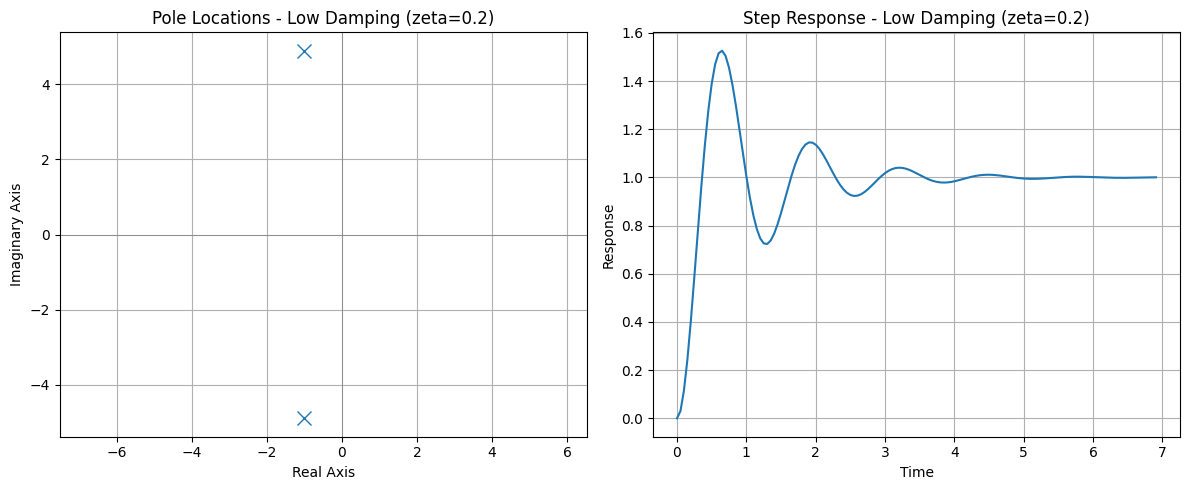

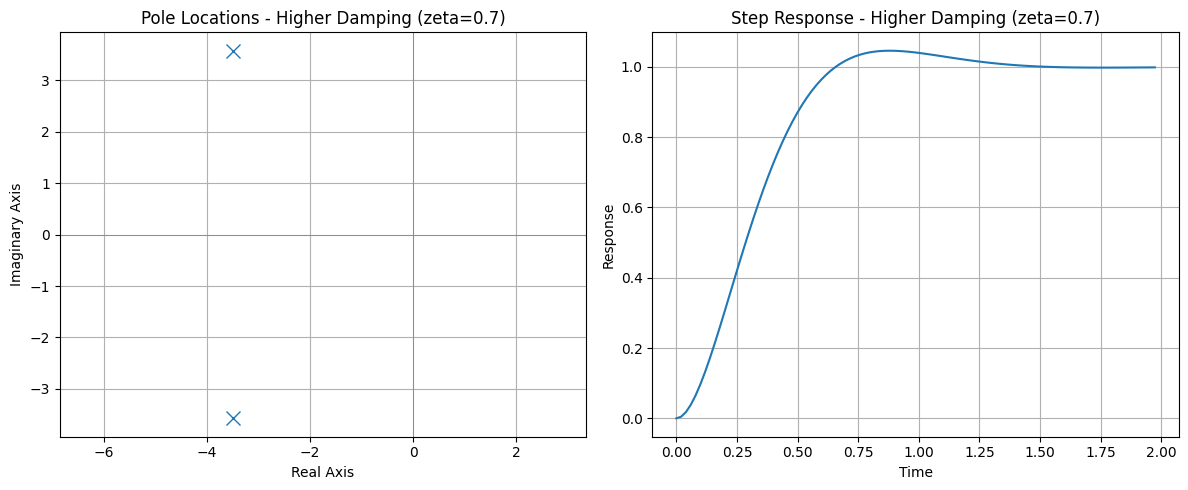

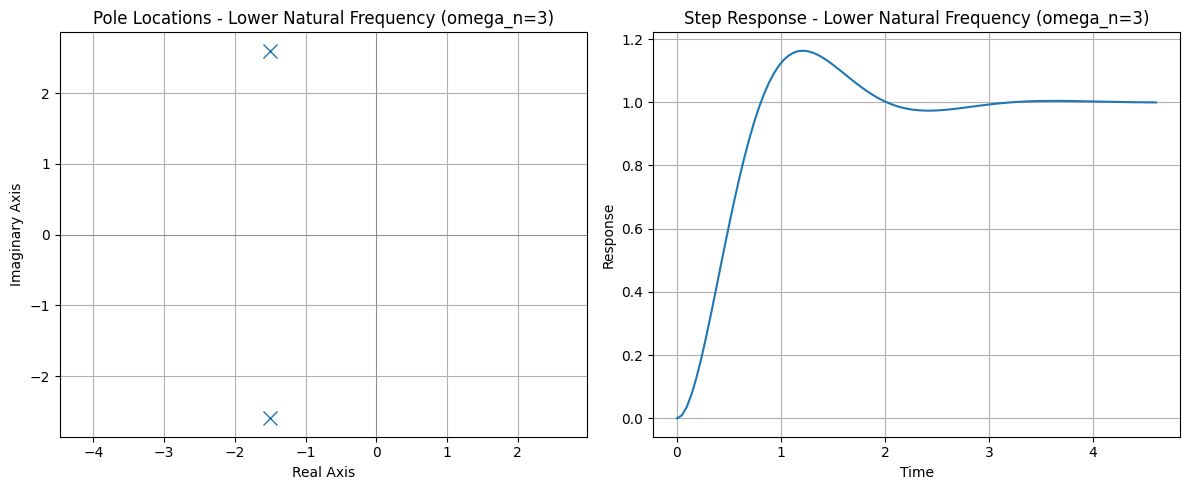

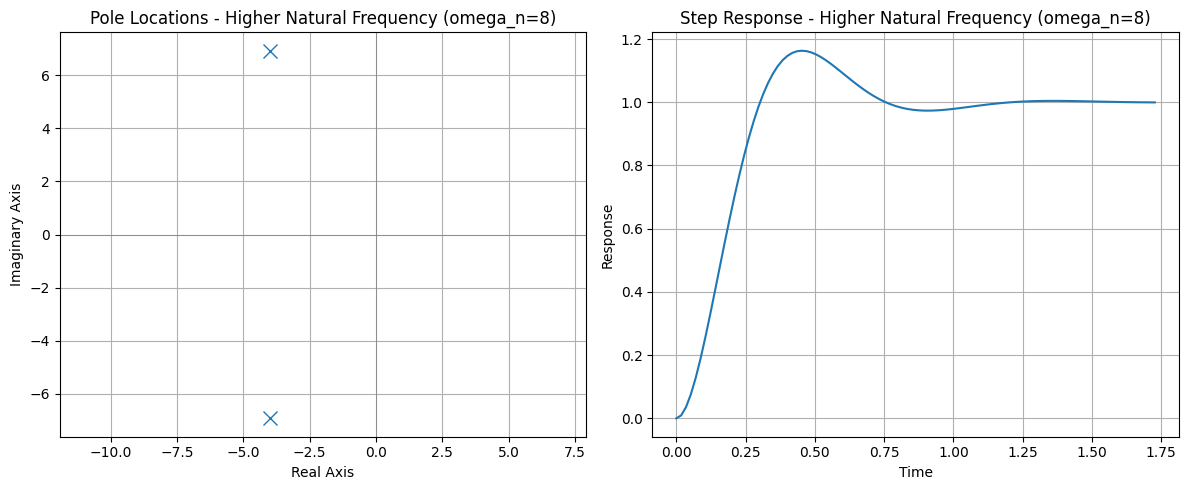

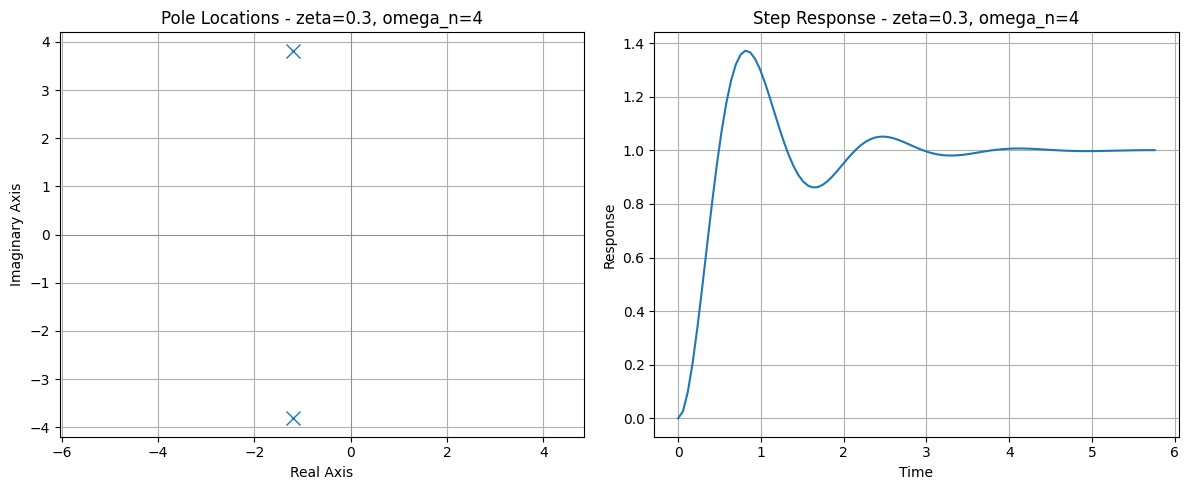

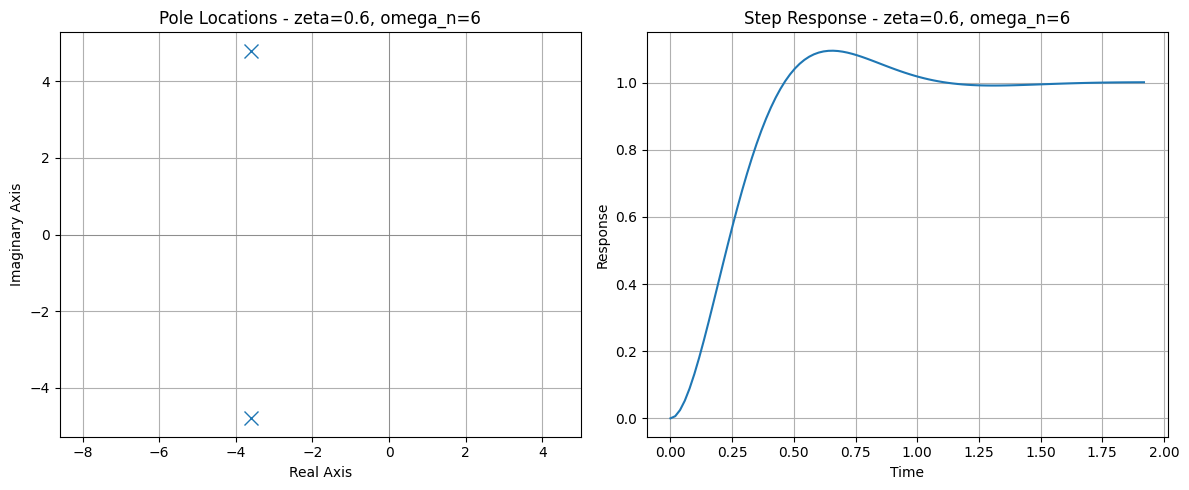

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import control

# Function to plot pole locations and step response
def plot_system_response(zeta, omega_n, title):
    # Calculate poles
    poles = np.roots([1, 2*zeta*omega_n, omega_n**2])

    # Create transfer function
    num = [omega_n**2]
    den = [1, 2*zeta*omega_n, omega_n**2]
    system = control.TransferFunction(num, den)

    # Plot poles
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(np.real(poles), np.imag(poles), 'x', markersize=10)
    plt.axhline(0, color='grey', lw=0.5)
    plt.axvline(0, color='grey', lw=0.5)
    plt.xlabel('Real Axis')
    plt.ylabel('Imaginary Axis')
    plt.title(f'Pole Locations - {title}')
    plt.grid(True)
    plt.axis('equal')

    # Plot step response
    t, y = control.step_response(system)
    plt.subplot(1, 2, 2)
    plt.plot(t, y)
    plt.xlabel('Time')
    plt.ylabel('Response')
    plt.title(f'Step Response - {title}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example 1: Varying zeta (constant omega_n)
omega_n = 5
plot_system_response(0.2, omega_n, 'Low Damping (zeta=0.2)')
plot_system_response(0.7, omega_n, 'Higher Damping (zeta=0.7)')

# Example 2: Varying omega_n (constant zeta)
zeta = 0.5
plot_system_response(zeta, 3, 'Lower Natural Frequency (omega_n=3)')
plot_system_response(zeta, 8, 'Higher Natural Frequency (omega_n=8)')

# Example 3: Varying both zeta and omega_n
plot_system_response(0.3, 4, 'zeta=0.3, omega_n=4')
plot_system_response(0.6, 6, 'zeta=0.6, omega_n=6')

En los gráficos de la izquierda, puedes observar la ubicación de los polos en el plano s. El eje horizontal representa la parte real ($\sigma$) y el eje vertical representa la parte imaginaria ($\omega_d$).

- **Ejemplo 1 (Varying zeta):**
    - Cuando $\zeta$ es bajo (0.2), los polos están más cerca del eje imaginario (mayor $\theta$), lo que resulta en un sobreimpulso significativo y oscilaciones que tardan más en decaer en la respuesta transitoria (gráfico de la derecha).
    - Cuando $\zeta$ es mayor (0.7), los polos están más cerca del eje real (menor $\theta$), lo que reduce el sobreimpulso y las oscilaciones decaen más rápidamente.

- **Ejemplo 2 (Varying omega_n):**
    - Cuando $\omega_n$ es menor (3), los polos están más cerca del origen. La frecuencia de oscilación ($\omega_d$) es menor, y la respuesta transitoria es más lenta.
    - Cuando $\omega_n$ es mayor (8), los polos están más lejos del origen. La frecuencia de oscilación ($\omega_d$) es mayor, y la respuesta transitoria es más rápida con oscilaciones más rápidas.

- **Ejemplo 3 (Varying both):**
    - Puedes ver cómo la combinación de $\zeta$ y $\omega_n$ afecta la posición de los polos y la respuesta transitoria. Polos más a la izquierda y/o más alejados del eje real implican respuestas más rápidas y/o con mayor frecuencia de oscilación, dependiendo de la relación entre $\zeta$ y $\omega_n$.

En resumen, la ubicación de los polos en el plano s, determinada por $\zeta$ y $\omega_n$ (o equivalentemente por $\sigma$ y $\omega_d$), es fundamental para entender y predecir la respuesta transitoria de un sistema de segundo orden. $\sigma$ controla la velocidad de decaimiento, $\omega_d$ controla la frecuencia de oscilación y $\theta$ (relacionado con $\zeta$) controla el sobreimpulso.